# Deep Learning - Predicting Proteome from Transcriptome

## Dependency import

In [1]:
import torch
from RnaToProteinDataModule.Dataset_classes import StandardDatasetProcessor
from RnaToProteinDataModule import make_nas14
from sklearn.metrics import r2_score
from scipy.stats import spearmanr
from statsmodels.stats.multitest import fdrcorrection
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os

## R2 Calculation

### Load Data

In [2]:
randomSeed = 4
randomSeed_dataSplit = 2

In [3]:
torch.manual_seed(randomSeed)

dataProcessor = StandardDatasetProcessor(random_state=randomSeed_dataSplit, isOnlyCodingTranscripts=False)
#dataProcessor.debug = True
dataProcessor.prepare_data()
dataProcessor.synchronize_all_datasets()
dataProcessor.split_full_dataset()
categories = "0"

model_save_path = "figure2_datasets/model.pth"
model, dataModule = make_nas14(dataProcessor, model_save_path)


         A1BG    A2M   AAAS   AACS  AAGAB   AAK1  AAMDC   AAMP   AAR2  AARS1  \
01BR001  3.51  12.93   9.41   9.57   9.75  10.12   8.10  11.25   9.87  11.92   
01BR008  2.84  13.02  10.17   9.02  10.61   9.88   7.91  11.58  10.21  12.34   
01BR009  4.85  13.68  10.18   9.74   9.74   9.61   7.47  11.04   9.98  12.06   
01BR010  4.24  12.64   9.90  11.88  10.12  10.29   8.27  11.55  10.73  11.55   
01BR015  3.89  13.55  10.03  10.28  10.13   9.40   7.29  10.57  10.63  11.16   
...       ...    ...    ...    ...    ...    ...    ...    ...    ...    ...   
21BR002  0.00  13.96  10.56   9.47  11.28  10.20   9.14  11.54  10.53  10.90   
21BR010  3.50  14.57   9.88   8.28  11.88  10.74   7.57   9.81   9.37  10.74   
22BR005  3.39  13.90   9.91   9.82  11.43  10.36   8.31  12.18  10.38  12.29   
22BR006  2.59  13.98  10.05   9.19  10.58   9.00   8.04  10.91   9.62  10.42   
604      0.00  12.73  10.80   9.72  10.11   9.57   9.83  12.01  11.47  12.94   

         ...  ZUP1  ZWINT  ZXDA   ZXDB 

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/cranneyc/miniforge3/envs/nas_paper/lib/python3.11/site-packages/pytorch_lightning/loops/utilities.py:73: `max_epochs` was not set. Setting it to 1000 epochs. To train without an epoch limit, set `max_epochs=-1`.
/Users/cranneyc/miniforge3/envs/nas_paper/lib/python3.11/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /Users/cranneyc/Documents/Projects/CPTAC_analysis/RnaToProteinDataModule/scripts/jupyter_notebooks/figures/checkpoints exists and is not empty.

  | Name   | Type                | Params | Mode 
-------------------------------------------------------
0 | layer1 | FullyConnectedBlock | 18.9 M | train
1 | layer2 | Resnet3Block        | 682 K  | train
2 | layer3 | FullyConnectedBlock | 65.2 M | train
-------------------------------------------------------
84.8 M    Trainable params
0         Non-trainable params
84.8 M

Sanity Checking: |                                                                                            …

/Users/cranneyc/miniforge3/envs/nas_paper/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/Users/cranneyc/miniforge3/envs/nas_paper/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Training: |                                                                                                   …

...

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

In [4]:
transcriptome, proteome, _ = dataProcessor.extract_full_dataset()
X_val_normalized = dataProcessor.X_val

In [5]:
transcriptome.to_csv('figure2_datasets/transcriptome.csv')
proteome.to_csv('figure2_datasets/proteome.csv')

### Calculate r2, spearman

In [6]:
def extract_yHat_and_y(model, dataloader):
    model.eval()
    with torch.no_grad():
        y_hat_torches = []
        y_torches = []
        for data, target in dataloader:
            y_hat_torches.append(model(data))
            y_torches.append(target)
        y_hat = torch.cat(y_hat_torches).cpu().data.numpy()
        y = torch.cat(y_torches).cpu().data.numpy()
        return y_hat, y

In [7]:
def basic_linear_regression_r2(x, y):
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    return r_value**2

In [8]:
validloader = dataModule.val_dataloader()

y_hat, y = extract_yHat_and_y(model, validloader)
print(X_val_normalized[:,0].shape)
print(y[:,0].shape)
r2scores = []
pval=[]
rhos= []
mRNAs = []
mRNA_linear_regression = []
proteins = list(proteome.columns)
transcripts = list(transcriptome.columns)
for i in range(len(proteins)):
    r2scores.append(r2_score(y[:,i], y_hat[:,i]))
    mRNAs.append(r2_score(y[:,i], X_val_normalized[:,i]))
    mRNA_linear_regression.append(basic_linear_regression_r2(y[:,i], X_val_normalized[:,i]))
    tmp_rho, tmp_p = spearmanr(y[:,i], y_hat[:,i])
    rhos.append(tmp_rho)
    pval.append(tmp_p)
r2scores[np.argmax(r2scores)]

(125,)
(125,)


0.8455591201782227

In [9]:
prot_r2 = pd.DataFrame({'protein':proteome.columns, 
                        'r2score':r2scores,
                       'rho':rhos,
                        'p-values':pval,
                        'r2_mRNA_protein':mRNAs,
                        'r2_mRNA_protein_basic_linear_regression':mRNA_linear_regression,
                       })#.sort_values('r2score',ascending=False)

In [10]:
prot_r2['p-val adj. BH'] = fdrcorrection(prot_r2['p-values'])[1]
prot_r2 = prot_r2.sort_values('p-val adj. BH')
prot_r2[prot_r2['protein']=='BGN']
print(prot_r2.shape)
prot_r2

(7822, 7)


,protein,r2score,rho,p-values,r2_mRNA_protein,r2_mRNA_protein_basic_linear_regression,p-val adj. BH
6379,SMC2,0.845559,0.903343,4.805497e-47,0.324860,0.478857,1.879430e-43
1495,CRTAP,0.812610,0.903588,4.140665e-47,-0.955569,0.000013,1.879430e-43
2354,FERMT2,0.783255,0.902519,7.890793e-47,0.374438,0.473501,2.057393e-43
4679,P4HA2,0.770355,0.901733,1.262045e-46,0.102988,0.323384,2.467929e-43
3326,KANK2,0.728678,0.901346,1.587914e-46,0.493675,0.516074,2.484132e-43
...,...,...,...,...,...,...,...
7775,ZNF362,-0.056291,-0.000716,9.936770e-01,-0.625992,0.004419,9.941854e-01
3107,IGHV3-64,-0.210438,-0.000701,9.938128e-01,-0.710962,0.000016,9.941941e-01
1858,DOLPP1,-0.126655,-0.000544,9.951944e-01,-0.739171,0.007931,9.954489e-01
2321,FBXO9,-0.166573,-0.000215,9.980996e-01,-0.836130,0.004487,9.982272e-01


In [11]:
prot_r2.to_csv('figure2_datasets/r2_rho_pvalues.csv', index=False)

## Scatterplot - BGN protein

In [12]:
# BGN scatterplot
proteinTarget = 'BGN'
print(len(transcriptome))
print(transcriptome.shape)
mrna_column = np.where(transcriptome.columns==proteinTarget)
protein_column = np.where(proteome.columns==proteinTarget)
print(mrna_column[0][0])
print(X_val_normalized.shape)
t = X_val_normalized[:,mrna_column[0][0]]
p = y[:, protein_column[0][0]]
p_hat = y_hat[:, protein_column[0][0]]
df = pd.DataFrame({'Protein': p, 'Predicted Protein': p_hat, 'Transcript': t})
df

1256
(1256, 59286)
690
(125, 59286)


,Protein,Predicted Protein,Transcript
0,-1.554134,-1.141766,-0.945076
1,0.882710,1.397780,0.947223
2,1.623978,1.117858,-0.045766
3,-0.412370,-0.887536,-0.645306
4,-0.643562,-0.508355,0.132223
...,...,...,...
120,-1.288268,-0.355377,0.041627
121,-0.100756,-0.037386,-1.377303
122,0.972120,0.607733,-0.856064
123,0.774835,0.064594,-0.769190


0.6794642210006714


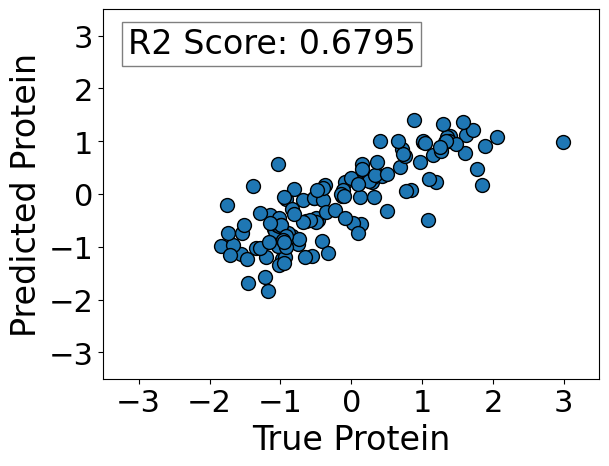

-0.626793384552002


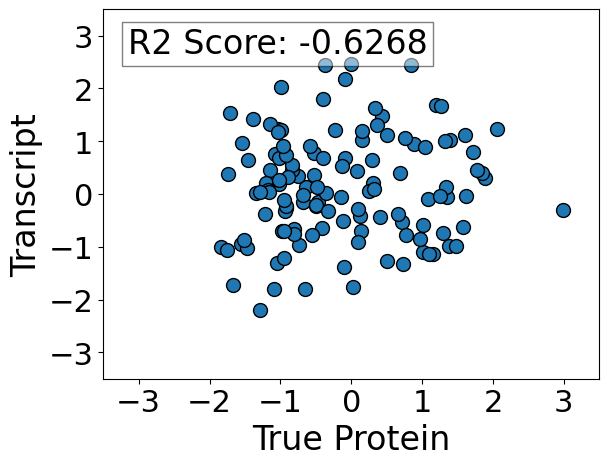

In [13]:
# Create scatter plots comparing the first column to each other column
for column in df.columns[1:]:
    plt.clf()
    plt.scatter(df.iloc[:, 0], df[column], label=column, s=100, edgecolor='black')
    # Adding labels and title
    r2 = r2_score(df.iloc[:, 0], df[column])
    r2_text = f'R2 Score: {round(r2, 4)}'
    print(r2)
    plt.ylim(-3.5, 3.5)
    plt.xlim(-3.5, 3.5)
    plt.xlabel('True Protein', fontsize=24)
    plt.ylabel(column, fontsize=24)
    plt.xticks(fontsize=22)
    plt.yticks(fontsize=22)
    plt.text(0.05, 0.95, r2_text, transform=plt.gca().transAxes, 
         fontsize=24, ha='left', va='top', bbox=dict(facecolor='white', alpha=0.5))

    plt.savefig(f'figure2_figures/{column}_scatterplot.png', bbox_inches='tight')
    plt.show()

## R2 Overlapping Histogram

### Some metrics

In [14]:
### how many are above zero ???
#np.where(r2scores>0)

def condition(x, val):
    return x > val
# Create the list
# Count the number of matching elements
print('ML protein predictions R2 score over 0: ', sum(condition(x, 0) for x in prot_r2.r2score))
print('ML protein predictions R2 score over 0.5: ', sum(condition(x, 0.5) for x in prot_r2.r2score))

ML protein predictions R2 score over 0:  6947
ML protein predictions R2 score over 0.5:  1764


In [15]:
print('mRNA protein predictions R2 score over 0: ', sum(condition(x, 0) for x in prot_r2.r2_mRNA_protein))
print('mRNA protein predictions R2 score over 0.5: ', sum(condition(x, 0.5) for x in prot_r2.r2_mRNA_protein))

mRNA protein predictions R2 score over 0:  2810
mRNA protein predictions R2 score over 0.5:  392


### Figure code

In [16]:
plt.rcParams['figure.figsize'] = [12, 9]
plt.rcParams['figure.dpi'] = 50 # 200 e.g. is really fine, but slower

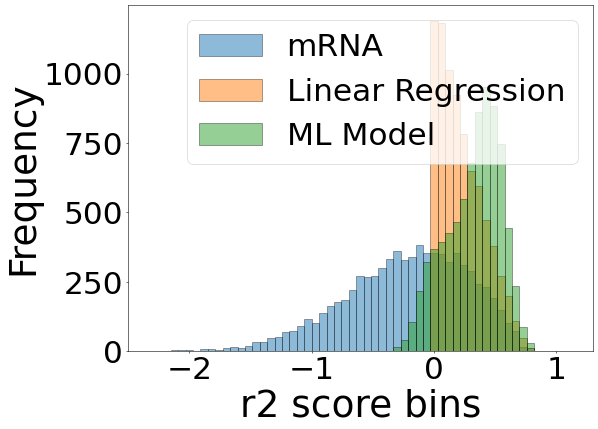

<Figure size 150x100 with 0 Axes>

In [17]:
fig, ax = plt.subplots(figsize=(12, 9))  # Adjust width and height as needed

ax.hist(prot_r2.r2_mRNA_protein, alpha=0.5, label='mRNA', bins=np.linspace(-5,1,100), edgecolor='black')
ax.hist(prot_r2.r2_mRNA_protein_basic_linear_regression, alpha=0.5, label='Linear Regression', bins=np.linspace(-5,1,100), edgecolor='black')
ax.hist(prot_r2.r2score, alpha=0.5, label='ML Model', bins=np.linspace(-5,1,100), edgecolor='black')

ax.set_xlim(left=-2.5)
# Adding labels and title
ax.set_xlabel('r2 score bins', fontsize=54)
ax.set_ylabel('Frequency', fontsize=54)
ax.tick_params(axis='x', labelsize=45)
ax.tick_params(axis='y', labelsize=45)

# Adding legend
legend = ax.legend(fontsize=45)
plt.show()
ax.legend_.remove()  # Remove the legend from the boxplot figure

fig.savefig('figure2_figures/r2_plot.svg', bbox_inches='tight')

fig_legend = plt.figure(figsize=(3, 2))
labels = [text.get_text() for text in legend.texts]  # Get the actual text strings
fig_legend.legend(legend.legend_handles, labels, loc='center', fontsize=45)
fig_legend.tight_layout()
fig_legend.savefig('figure2_figures/r2_plot_legend.svg', bbox_inches='tight')
plt.show()

### NAS Graph

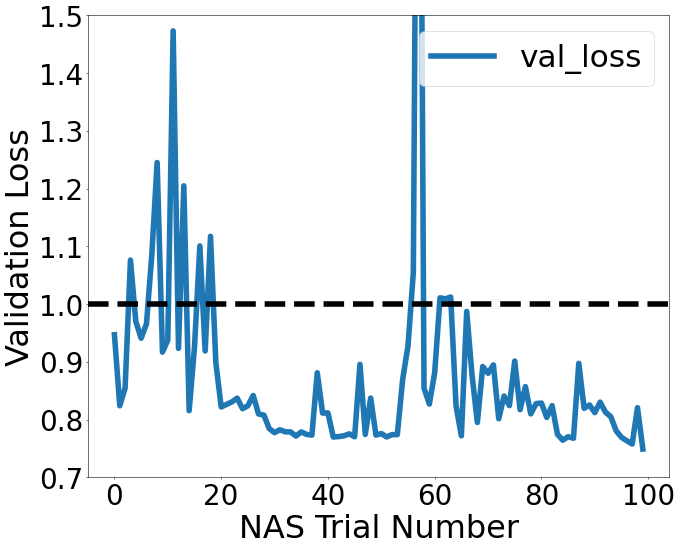

In [18]:
df = pd.read_csv('figure2_datasets/DO_NOT_DELETE_sample_dataset_nas_output_20240229-172748_full13.csv').sort_values('trial_index')
#df = pd.read_csv('figure2_datasets/DO_NOT_DELETE_sample_dataset_nas_output_20240303-083726_full14.csv').sort_values('trial_index')

# Plotting the DataFrame
df.plot(x='trial_index', y='val_loss', kind='line', figsize=(15, 12), linewidth=8)

plt.ylim(0.7, 1.5)
plt.axhline(y=1, color='black', linestyle='--', linewidth=8)

plt.xlabel('NAS Trial Number', fontsize=46)
plt.ylabel('Validation Loss', fontsize=46)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
plt.legend(fontsize=45)
#plt.grid(True)
plt.savefig('figure2_figures/NAS_val_loss_over_time.png', bbox_inches='tight')
plt.show()